# Edge IIoT - Explainable AI

In [33]:
# Instalar shap si no lo tienes instalado (descomentar la siguiente línea)
# !pip install shap joblib matplotlib pandas scikit-learn

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import shap
import numpy as np

# Configurar el estilo de los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
shap.initjs() # Inicializar Javascript para visualizaciones interactivas de SHAP

## 1. Getting the data

In [34]:
%load_ext autoreload
%autoreload 2

from src.config import DATASETS

# Seleccionamos el dataset a analizar
dataset_name = "edge_iiot"
config = DATASETS[dataset_name]

print("\n--- Dataset Information ---")
print(f"Name: {dataset_name.upper()}")
print(f"Path: {config['processed_path']}\n")

filename = "ML-EdgeIIoT-dataset"

csv_path = config['processed_path'] / f"{filename}.pkl"
print(f"CSV Path: {csv_path}\n")

print("Loading dataset... (This may take a while)")
df = pd.read_pickle(csv_path)

print(f"\nDataset loaded with shape: {df.shape}")

model_path = config['binary_model_path'] / f"model_rf.pkl"
model = joblib.load(model_path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

--- Dataset Information ---
Name: EDGE_IIOT
Path: /home/uo294319/ML-NIDS-IIoT/data/processed/edge_iiot

CSV Path: /home/uo294319/ML-NIDS-IIoT/data/processed/edge_iiot/ML-EdgeIIoT-dataset.pkl

Loading dataset... (This may take a while)

Dataset loaded with shape: (155027, 59)


In [35]:
df_naive = df.select_dtypes(include=['number'])
X = df_naive.drop(columns=['Attack_label'])
categorical_cols = X.select_dtypes(include=['str', 'object', 'category']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

## 2. Random Forest Explainability

### 2.1 Feature Importances

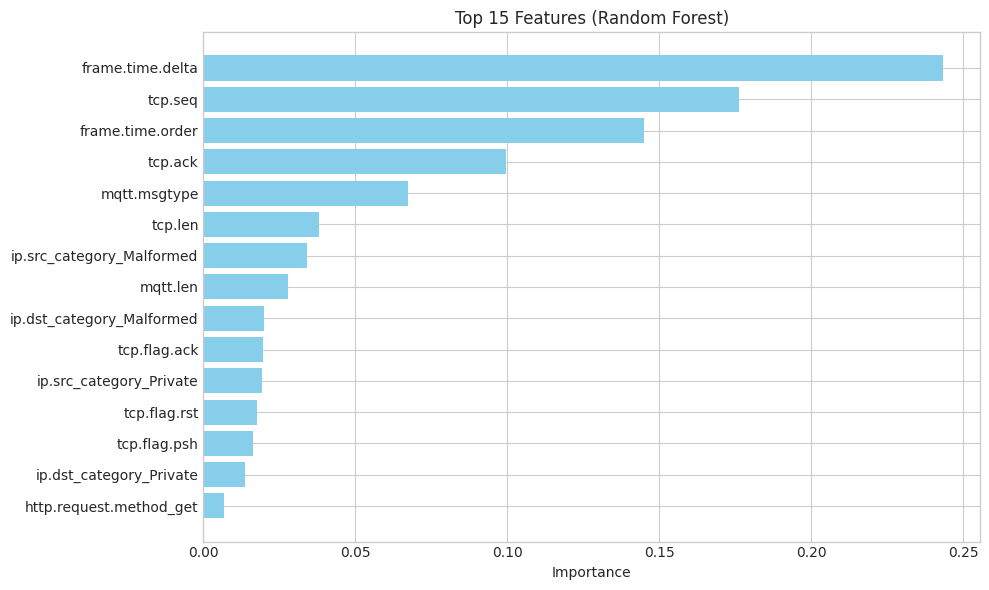

In [ ]:
top_n = 15

importances = model.feature_importances_
feature_names = X.columns

df_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

df_top = df_importances.tail(top_n)

plt.figure(figsize=(10, 6))
plt.barh(df_top['Feature'], df_top['Importance'], color='skyblue')
plt.title(f'Top {top_n} Features (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 2.2 SHAP

In [37]:
n_sample = 1000
if X.shape[0] > n_sample:
    X_sample = X.sample(n_sample, random_state=42)
else:
    X_sample = X.copy()

print(f"Ramdomly extracted {X_sample.shape[0]} observations for SHAP calculation.")

Ramdomly extracted 1000 observations for SHAP calculation.


In [38]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)
shap_obj = explainer(X_sample)

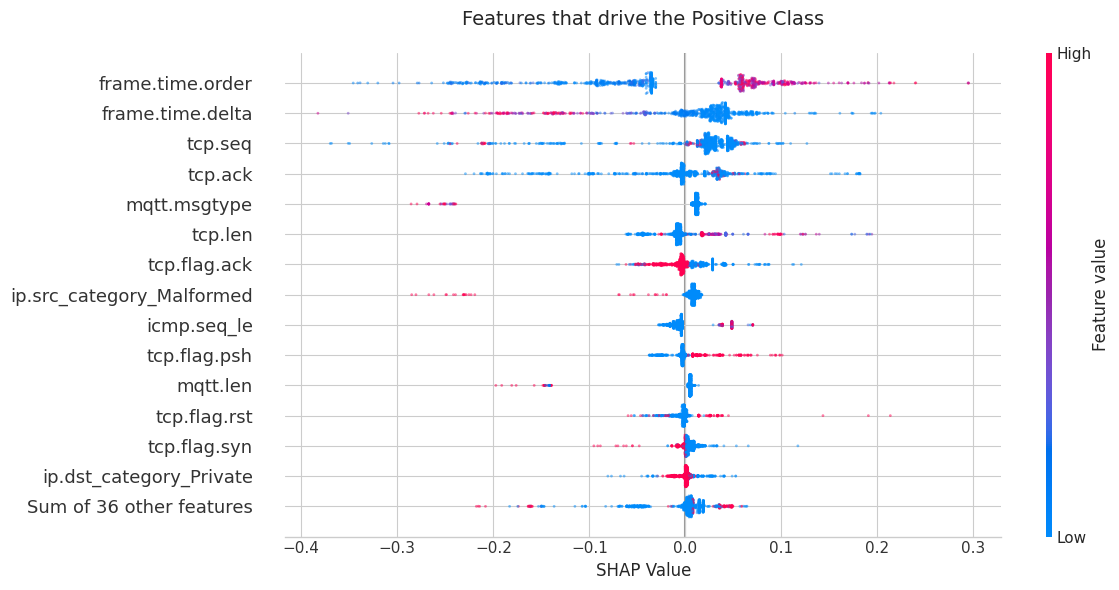

In [39]:
plt.figure(figsize=(12, 6))
shap.plots.beeswarm(
    shap_obj[:, :, 1], 
    max_display=top_n, 
    s=4,
    alpha=0.5,
    plot_size=None,
    show=False
)

plt.title("Features that drive the Positive Class", fontsize=14, pad=20)
plt.xlabel("SHAP Value", fontsize=12)
plt.tight_layout()
plt.show()

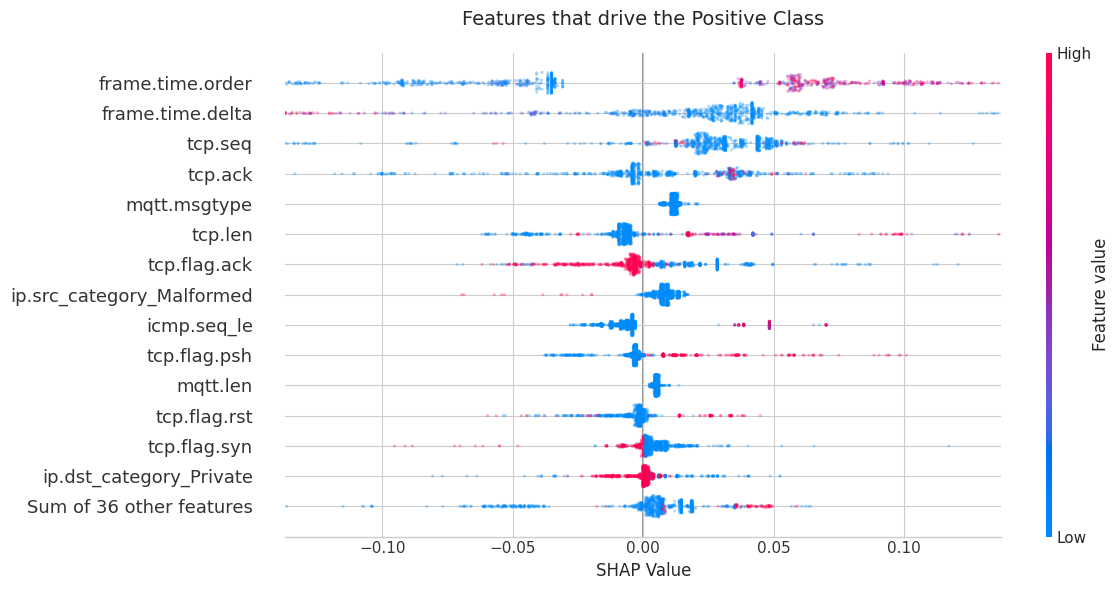

In [49]:
plt.figure(figsize=(12, 6))
shap.plots.beeswarm(
    shap_obj[:, :, 1], 
    max_display=top_n, 
    s=5,
    alpha=0.3,
    plot_size=None,
    show=False
)

limit = np.percentile(np.abs(shap_obj[:, :, 1].values), 99)
plt.xlim(-limit, limit)

plt.title("Features that drive the Positive Class", fontsize=14, pad=20)
plt.xlabel("SHAP Value", fontsize=12)
plt.tight_layout()
plt.show()